# Q14.
```{admonition}
:class: note
This problem focuses on the *collinearity* problem.

In [ ]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pandas as pd
from ISLP.models import summarize

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot

## (a)
```{admonition}
:class: note
After running the code block below, write out the form of the linear model and its regression coefficients.

In [ ]:
rng = np.random.default_rng(1728)
x1 = rng.uniform(0, 1, size =100)
x2 = 0.5 * x1 + rng.normal(size =100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size =100)

The linear model takes the form $Y = 2+2X_{1}+0.3X_{2}$ with regression coefficients $\beta_{0} = 2$, $\beta_{1} = 2$, and $\beta_{2} = 0.3$.

## (b)
```{admonition}
:class: note
What is the correlation between `x1` and `x2`? Create a scatterplot displaying the relationship between the variables.

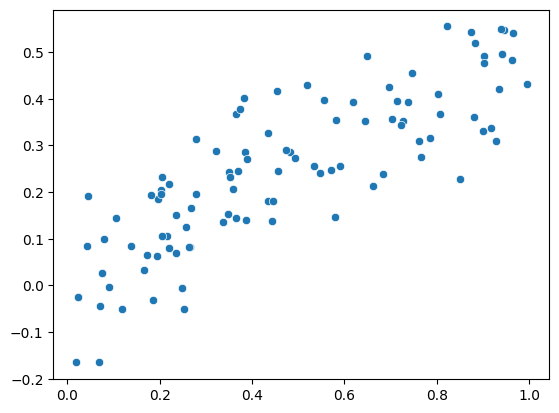

[[1.        0.8269157]
 [0.8269157 1.       ]]


In [ ]:
sns.scatterplot(x=x1,y=x2)
plt.show()
print(np.corrcoef(x1,x2))

## (c)
```{admonition}
:class: note
Using this data, fit least squares regression to predict `y` using `x1` and `x2`. What are $\hat{\beta_{0}}$, $\hat{\beta_{1}}$, and $\hat{\beta_{2}}$? How do these relate to the true $\beta_{0}$, $\beta_{1}$, and $\beta_{2}$? Can you reject the null hypothesis $H_{0}: \beta_{1} = 0$? How about the null hypothesis $H_{0}: \beta_{2} = 0$?

In [ ]:
df = pd.DataFrame({'y':y,'x1':x1,'x2':x2})
model_x1x2 = smf.ols('y ~ x1+x2', data=df).fit()
summarize(model_x1x2)

,coef,std err,t,P>|t|
Intercept,2.0083,0.183,10.977,0.000
x1,2.5098,0.585,4.294,0.000
x2,-0.2621,1.005,-0.261,0.795


In [ ]:
b0, b1, b2 = model_x1x2.params
print(f'The estimated coefficients are: {b0:.4f}, {b1:.4f}, and {b2:.4f}')
print('The intercept is close, but the x1 and x2 coefficients are both off by about 0.5. This also caused the x2 coefficient to become negative.')
print('We can reject the null hypothesis for x1\'s coefficient, but not for x2\'s.')

The estimated coefficients are: 2.0083, 2.5098, and -0.2621
The intercept is close, but the x1 and x2 coefficients are both off by about 0.5. This also caused the x2 coefficient to become negative.
We can reject the null hypothesis for x1's coefficient, but not for x2's.


## (d)
```{admonition}
:class: note
Now fit a least squares regression to predict `y` using only `x1`. Can you reject the null hypothesis $H_{0}: \beta_{1} = 0$?

In [ ]:
model_x1 = smf.ols('y ~ x1', data=df).fit()
summarize(model_x1)

,coef,std err,t,P>|t|
Intercept,2.0030,0.181,11.069,0.0
x1,2.3838,0.327,7.287,0.0


## (e)
```{admonition}
:class: note
Now fit a least squares regression to predict `y` using only `x2`. Can you reject the null hypothesis $H_{0}: \beta_{1} = 0$?

There is sufficient evidence to reject the null.

In [ ]:
model_x2 = smf.ols('y ~ x2', data=df).fit()
summarize(model_x2)

,coef,std err,t,P>|t|
Intercept,2.3131,0.183,12.64,0.0
x2,3.3076,0.614,5.39,0.0


There is sufficient evidence to reject the null.

## (f)
```{admonition}
:class: note
Do the results obtained in (c)-(e) contradict each other?

The questions being asked in each part are distinct, namely they are asking about different models, so they do not contradict anything.

## (g)
```{admonition}
:class: note
Suppose we obtain one additional observation, which was unfortunately mismeasured. We use the function `np.concatenate()` below to add this additional observation to each of `x1`, `x2` and `y`. Re-fit the linear models from (c) to (e) using this new data. What effect does this new observation have on the each of the models? In each model, is this observation an outlier? A high-leverage point? Both?

In [ ]:
x1 = np.concatenate([x1 , [0.1]])
x2 = np.concatenate([x2 , [0.8]])
y = np.concatenate([y, [6]])

In [ ]:
df = pd.DataFrame({'y':y,'x1':x1,'x2':x2})

             coef  std err       t  P>|t|
Intercept  2.0441    0.192  10.668  0.000
x1         1.4198    0.506   2.807  0.006
x2         1.7734    0.833   2.130  0.036


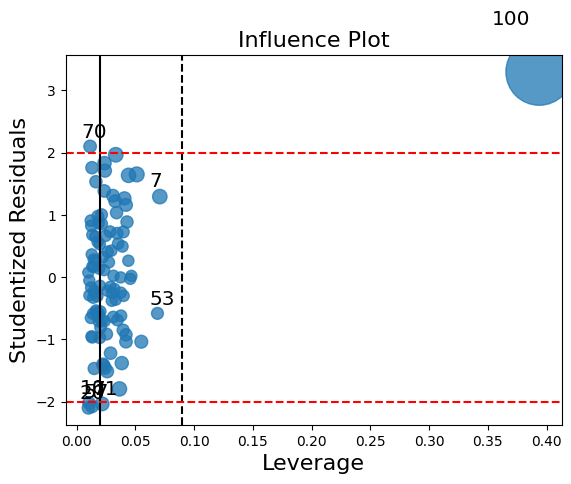

In [ ]:
model_x1x2_new = smf.ols('y ~ x1+x2', data=df).fit()
print(summarize(model_x1x2_new))
fig  = sm.graphics.influence_plot(model_x1x2_new)
ax = fig.get_axes()[0]
p = 2
n = 100
ax.axvline(3*(p+1)/n,color='black',linestyle='--')
ax.axvline(p/n,color='black',linestyle='-')
ax.axhline(-2,color='red',linestyle='--')
ax.axhline(2,color='red',linestyle='--');
plt.show()

             coef  std err       t  P>|t|
Intercept  2.1204    0.192  11.069    0.0
x1         2.2136    0.348   6.361    0.0


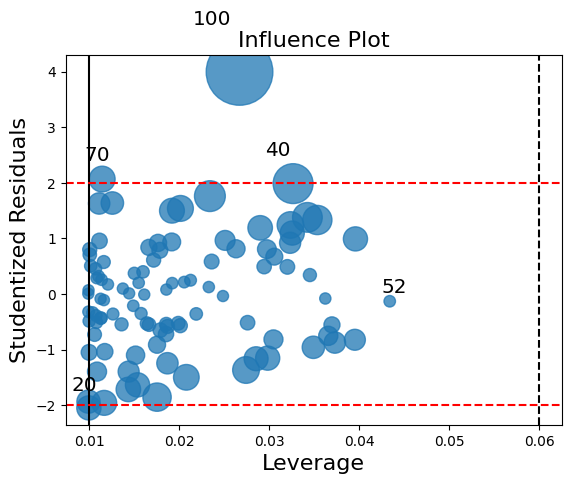

In [ ]:
model_x1_new = smf.ols('y ~ x1', data=df).fit()
print(summarize(model_x1_new))
fig  = sm.graphics.influence_plot(model_x1_new)
ax = fig.get_axes()[0]
p = 1
n = 100
ax.axvline(3*(p+1)/n,color='black',linestyle='--')
ax.axvline(p/n,color='black',linestyle='-')
ax.axhline(-2,color='red',linestyle='--')
ax.axhline(2,color='red',linestyle='--');
plt.show()

             coef  std err       t  P>|t|
Intercept  2.2757    0.179  12.724    0.0
x2         3.4956    0.582   6.005    0.0


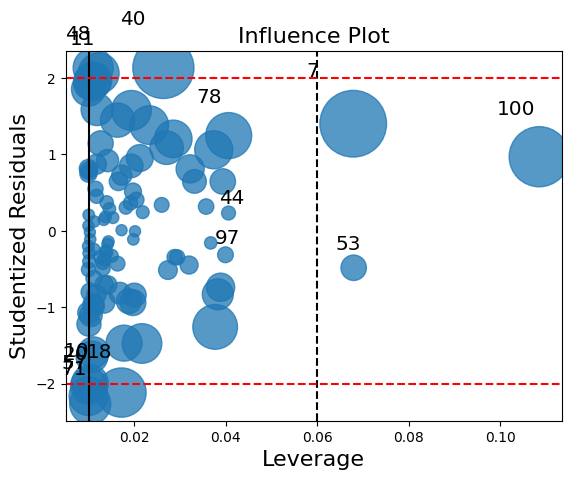

In [ ]:
model_x2_new = smf.ols('y ~ x2', data=df).fit()
print(summarize(model_x2_new))
fig  = sm.graphics.influence_plot(model_x2_new)
ax = fig.get_axes()[0]
p = 1
n = 100
ax.axvline(p/n,color='black',linestyle='-')
ax.axvline(3*(p+1)/n,color='black',linestyle='--')
ax.axhline(-2,color='red',linestyle='--')
ax.axhline(2,color='red',linestyle='--');
plt.show()

With both predictors, the added point is both an outlier and high leverage. With just `x1` the point is an outlier, and with just `x2` the point is high leverage.